In [57]:
from phd_helpers.paramOptimisation.getInfo import get_params3d, get_runtimes, combine_metric_dfs, score_value
from phd_helpers.paths import get_info_df, get_subject_stl_path, get_mesh, avg_edge_length
from phd_helpers.MeshQuality import check_mesh_quality, mesh_quality_summary, plot_bad_cells


from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from tqdm import tqdm
import subprocess

In [14]:
# -------- PATHS --------------------------------------------- #
root_dir = Path('../../../../MeshPipeline/outputs/ParamOptimisation/fullRuns') # path to parent of output_root in set_parameters
out_dir = Path('outputs/study4') # path dir to save outputs in

study_prefix = 'study4' # start of dir name of output_root in set_parameters
studies = [''] # individual study identifier (end of dir name of output_root in set_parameters)

In [15]:
get_runtimes(root_dir, study_prefix, studies).to_csv(out_dir / 'runtimes.csv', index=False)

info = get_info_df('CMC')

df_bone, df_cart, df_qual = combine_metric_dfs(out_dir, ['study4-0'])

df_bone.to_csv(out_dir / 'df_bone.csv', index=False)
df_cart.to_csv(out_dir / 'df_cart.csv', index=False)
df_qual.to_csv(out_dir / 'df_qual.csv', index=False)

In [16]:
# LOAD DATA

df_bone = pd.read_csv(out_dir / 'df_bone.csv')
df_cart = pd.read_csv(out_dir / 'df_cart.csv')
df_qual = pd.read_csv(out_dir / 'df_qual.csv')


df_run = pd.read_csv(out_dir / 'runtimes.csv')

In [66]:
bone = 'tpm'

d_metric2 = 'max'
d_metric1 = '99'
iteration_cart = 'orig'
iteration_bone = 'orig'
loc = 'i'

qual_metric = '99.9%'
qual_part = 'full'

metrics = [

    # fidelity (keep high)
    f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'bone_{iteration_bone}_d{loc}_{d_metric2}',
    f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'cart_{iteration_cart}_d{loc}_{d_metric2}',

    # quality (keep high)
    #f'{qual_part}_min_angle_{qual_metric}',
    #f'{qual_part}_scaled_jacobian_{qual_metric}',
    f'{qual_part}_min_angle_worst',
    f'{qual_part}_scaled_jacobian_worst',
    f'{qual_part}_aspect_ratio_worst',
    f'{qual_part}_radius_ratio_worst',

]


bone_df = df_bone[
    ['sub', 'bone', 'run_id', f'{iteration_bone}_d{loc}_{d_metric1}', f'{iteration_bone}_d{loc}_{d_metric2}', 'remesh3d_vol']
].rename(columns={
    f'{iteration_bone}_d{loc}_{d_metric1}': f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'{iteration_bone}_d{loc}_{d_metric2}': f'bone_{iteration_bone}_d{loc}_{d_metric2}'
})

cart_df = df_cart[
    ['sub', 'bone', 'run_id', f'{iteration_cart}_d{loc}_{d_metric1}', f'{iteration_cart}_d{loc}_{d_metric2}']
].rename(columns={
    f'{iteration_cart}_d{loc}_{d_metric1}': f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'{iteration_cart}_d{loc}_{d_metric2}': f'cart_{iteration_cart}_d{loc}_{d_metric2}'
})

qual = df_qual[
    [
        'sub', 'bone', 'run_id',
        #f'{qual_part}_min_angle_{qual_metric}',
        #f'{qual_part}_scaled_jacobian_{qual_metric}',
        f'{qual_part}_min_angle_worst',
        f'{qual_part}_scaled_jacobian_worst',
        #f'{qual_part}_aspect_ratio_{qual_metric}',
        #f'{qual_part}_radius_ratio_{qual_metric}',
        f'{qual_part}_aspect_ratio_worst',
        f'{qual_part}_radius_ratio_worst',
        'full_n_cells',
    ]
]

df = (
    bone_df
    .merge(cart_df, on=['sub', 'bone', 'run_id'], how='inner')
    .merge(qual, on=['sub', 'bone', 'run_id'], how='inner')
)

df = df[df['bone']==bone]

print(len(df))

36


Highest element count:
	14726R - 611066


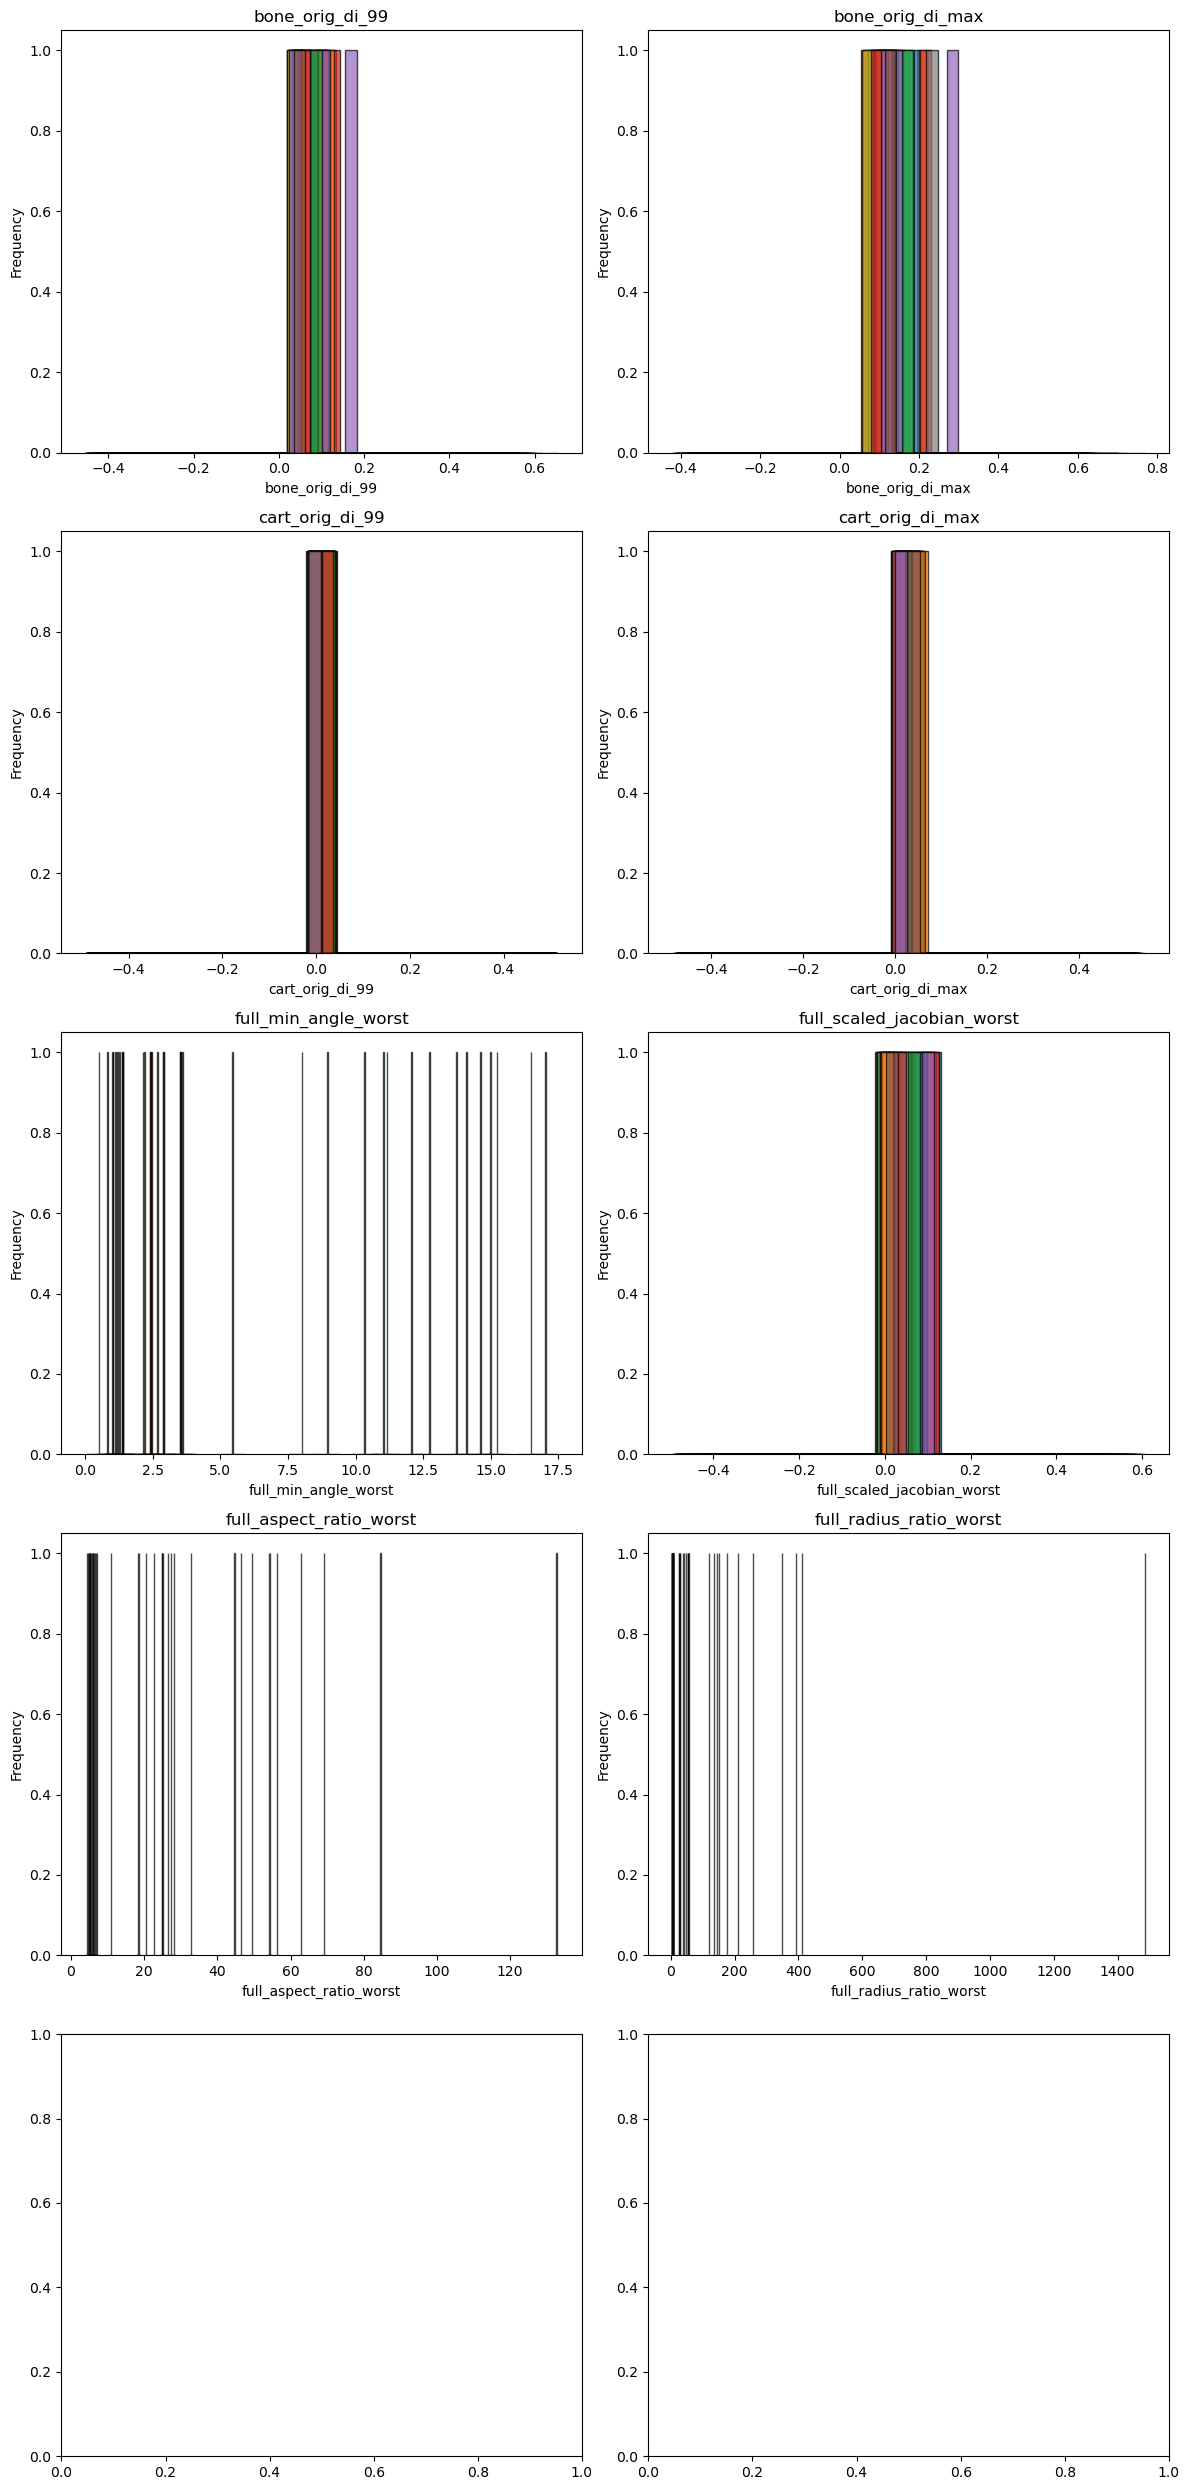

In [67]:
fig, ax = plt.subplots(5, 2, figsize=(12, 25))
ax = ax.flatten()

most_cells = qual.sort_values('full_n_cells').iloc[-1]
print(f'Highest element count:\n\t{most_cells['sub']} - {most_cells['full_n_cells']}')
for sub in df['sub'].unique():
    subject, side = sub[:-1], sub[-1]
    stl_path = get_subject_stl_path(subject, side)
    orig_bone = get_mesh(stl_path, 'tpm')
    L = avg_edge_length(orig_bone)
    #print(f"\n{sub}\n - Average edge length: {L:.4f} mm")
    #print(f' -   Max element count: {qual[qual['sub']==sub]['total_tets'].max()}')

    sub_df = df[df['sub']==sub]
    bins = len(df)
    for i, metric in enumerate(metrics):
        values = sub_df[metric]#[df_param['fd_bone']==0.8]
        # Histogram
        ax[i].hist(values, bins=bins, edgecolor='black', alpha=0.7, label=sub)
        ax[i].set_title(metric)
        ax[i].set_xlabel(metric)
        ax[i].set_ylabel('Frequency')

        #ax[i].legend()

plt.tight_layout()
plt.show()

### WHy are the top 14 all good , then sudden drop off for the rest???

In [63]:
qual.sort_values('full_radius_ratio_worst').reset_index(drop=True)

,sub,bone,run_id,full_min_angle_worst,full_scaled_jacobian_worst,full_aspect_ratio_worst,full_radius_ratio_worst,full_n_cells
0,14548R,tpm,0-0,17.003427,0.103752,4.352316,4.326900,177516
1,15006R,tpm,0-0,15.220278,0.107411,4.965209,4.680918,315718
2,50017L,tpm,0-0,14.100517,0.097905,4.639593,5.073871,272410
3,14827L,tpm,0-0,16.479411,0.097955,5.211019,5.149943,256298
4,14874R,tpm,0-0,13.713532,0.086589,5.501786,5.156031,473821
5,50037L,tpm,0-0,14.599818,0.081583,4.928017,5.266721,208141
6,50000R,tpm,0-0,14.966762,0.091742,5.249706,5.367590,230803
7,50049R,tpm,0-0,11.146696,0.085978,5.618281,5.453981,258226
8,50007L,tpm,0-0,8.932777,0.083181,6.353896,5.499400,180384
9,50027L,tpm,0-0,11.015094,0.058375,7.124288,5.913400,261030


In [ ]:
['14727R', '15294R', '50018L', '50001R', '14613R', '50016L']

In [53]:
path = '/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/outputs/ParamOptimisation/fullRuns/study4/meshes/14727R/tpm-mc1/3Dmesh/mesh-0-0-0.vtu'
mesh = pv.read(path)
mesh.plot()



Widget(value='<iframe src="http://localhost:49799/index.html?ui=P_0x3476c73b0_1&reconnect=auto" class="pyvista…

In [56]:
q = check_mesh_quality(mesh.extract_cells_by_type(10), 'tet')
mesh_quality_summary(q, 'tet')

min_angle 13/358118 cells outside of acceptable range (10, 70.53)
max_angle 7/358118 cells outside of acceptable range (70.53, 170)
radius_ratio 161/358118 cells outside of acceptable range (1.0, 3.0)
shape 62/358118 cells outside of acceptable range (0.4, 1.0)
aspect_ratio 440/358118 cells outside of acceptable range (1.0, 3.0)
scaled_jacobian 55/358118 cells outside of acceptable range (0.2, 1.0)
aspect_frobenius 427/358118 cells outside of acceptable range (1.0, 2.0)
condition 119/358118 cells outside of acceptable range (1.0, 3.0)


,mean,best,worst,acceptable_range,acceptable_range_pct,bad_cells,95%
metric,,,,,,,
min_angle,52.647191,69.858914,0.487788,"(10, 70.53)",99.996370,13,"(38.22, 69.86)"
max_angle,94.467372,71.262874,179.086140,"(70.53, 170)",99.998045,7,"(71.26, 116.56)"
radius_ratio,1.164565,1.000432,1485.943545,"(1.0, 3.0)",99.955043,161,"(1.0, 1.42)"
shape,0.896665,0.999665,0.035744,"(0.4, 1.0)",99.982687,62,"(0.76, 1.0)"
aspect_ratio,1.339012,1.009079,132.667744,"(1.0, 3.0)",99.877135,440,"(1.01, 1.69)"
scaled_jacobian,0.732304,0.990058,0.003652,"(0.2, 1.0)",99.984642,55,"(0.5, 0.99)"
aspect_frobenius,1.124470,1.000335,27.976696,"(1.0, 2.0)",99.880766,427,"(1.0, 1.32)"
condition,1.133301,1.000337,119.245079,"(1.0, 3.0)",99.966771,119,"(1.0, 1.35)"


In [58]:
plot_bad_cells(mesh, q, 'radius_ratio', 'tet')

radius_ratio
Bad cells =  161


Widget(value='<iframe src="http://localhost:49799/index.html?ui=P_0x33c72bfe0_2&reconnect=auto" class="pyvista…

In [ ]:
RE LOOK AT THESE RESULTS FOR PARAMS-10 
LOOK AT STUDY 5 RESULTS

CHECK POSTPROCESSING ABAQUS WORKED
WRITE BATCH SCRIPT AND RUN THOSE 3 FOR ALL POSES

FIGURE OUT HOW MANY NODES ABAQUS ON LAPTOP CAN HANDLE 

CHOOSE WHICH POSES TO USE

PLAN A FEA SENSITIVITY STUDY